In [21]:
# ============================================================
# CELL 1 — INSTALL (Optional)
# ============================================================

# Uncomment if needed

# !pip install rank-bm25 sentence-transformers faiss-cpu

In [22]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================

import faiss
import pickle
import numpy as np
import pandas as pd

from rank_bm25 import BM25Okapi

from sentence_transformers import SentenceTransformer

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [23]:
# ============================================================
# CELL 3 — CONFIG
# ============================================================

FAISS_INDEX_PATH = "../parquet_exports/ticket_similarity.index"

EMBEDDING_METADATA_PATH = (
    "../parquet_exports/embedding_metadata.parquet"
)

BM25_CORPUS_PATH = (
    "../parquet_exports/bm25_corpus.pkl"
)

EMBEDDING_MODEL_NAME = (
    "sentence-transformers/all-MiniLM-L6-v2"
)

TOP_K_FAISS = 20
TOP_K_BM25 = 20

RRF_K = 60

print("=" * 60)
print("CONFIG")
print("=" * 60)

print(f"Embedding Model : {EMBEDDING_MODEL_NAME}")

print(f"FAISS Top K     : {TOP_K_FAISS}")

print(f"BM25 Top K      : {TOP_K_BM25}")

print(f"RRF Constant    : {RRF_K}")

CONFIG
Embedding Model : sentence-transformers/all-MiniLM-L6-v2
FAISS Top K     : 20
BM25 Top K      : 20
RRF Constant    : 60


In [24]:
# ============================================================
# CELL 4 — LOAD FAISS INDEX
# ============================================================

index = faiss.read_index(
    FAISS_INDEX_PATH
)

print("=" * 60)
print("FAISS INDEX LOADED")
print("=" * 60)

print(f"Index Size : {index.ntotal:,}")

FAISS INDEX LOADED
Index Size : 230,088


In [25]:
# ============================================================
# CELL 5 — LOAD METADATA
# ============================================================

metadata_df = pd.read_parquet(
    EMBEDDING_METADATA_PATH
)

print("=" * 60)
print("METADATA LOADED")
print("=" * 60)

print(f"Rows    : {len(metadata_df):,}")
print(f"Columns : {metadata_df.shape[1]}")

metadata_df.head()

METADATA LOADED
Rows    : 230,088
Columns : 9


,chunk_id,document_id,ticket_pk,chunk_text,metadata_json,priority_encoded,urgency_encoded,impact_encoded,retrieval_quality_score
0,doc_0_chunk_0,doc_0,2013_2,prio_high urg_critical impact_medium ticket_un...,"{""ticket_pk"": ""2013_2"", ""source_system"": ""GLPI...",4.0,5.0,3.0,0.516667
1,doc_1_chunk_0,doc_1,2013_3,prio_medium urg_medium impact_medium ticket_un...,"{""ticket_pk"": ""2013_3"", ""source_system"": ""GLPI...",3.0,3.0,3.0,0.516667
2,doc_2_chunk_0,doc_2,2013_4,prio_medium urg_medium impact_medium ticket_un...,"{""ticket_pk"": ""2013_4"", ""source_system"": ""GLPI...",3.0,3.0,3.0,0.650000
3,doc_3_chunk_0,doc_3,2013_5,prio_critical urg_critical impact_high ticket_...,"{""ticket_pk"": ""2013_5"", ""source_system"": ""GLPI...",5.0,5.0,4.0,0.516667
4,doc_4_chunk_0,doc_4,2013_6,prio_medium urg_medium impact_medium ticket_un...,"{""ticket_pk"": ""2013_6"", ""source_system"": ""GLPI...",3.0,3.0,3.0,0.516667


In [26]:
# ============================================================
# CELL 6 — LOAD BM25 CORPUS
# ============================================================

bm25_tokens = pd.read_pickle(
    BM25_CORPUS_PATH
)

print("=" * 60)
print("BM25 CORPUS LOADED")
print("=" * 60)

print(f"Documents : {len(bm25_tokens):,}")

BM25 CORPUS LOADED
Documents : 230,088


In [27]:
# ============================================================
# CELL 7 — BUILD BM25 INDEX
# ============================================================

bm25 = BM25Okapi(
    bm25_tokens.tolist()
)

print("=" * 60)
print("BM25 INDEX CREATED")
print("=" * 60)

BM25 INDEX CREATED


In [28]:
# ============================================================
# CELL 8 — LOAD EMBEDDING MODEL
# ============================================================

embedding_model = SentenceTransformer(
    EMBEDDING_MODEL_NAME
)

print("=" * 60)
print("EMBEDDING MODEL LOADED")
print("=" * 60)

EMBEDDING MODEL LOADED


In [29]:
# ============================================================
# CELL 9 — BM25 SEARCH FUNCTION
# ============================================================

def bm25_search(
    query: str,
    top_k: int = 10
):

    tokenized_query = (
        query.lower().split()
    )

    scores = bm25.get_scores(
        tokenized_query
    )

    top_indices = np.argsort(scores)[::-1][:top_k]

    results = []

    for rank, idx in enumerate(top_indices):

        row = metadata_df.iloc[idx]

        results.append({
            "retriever": "bm25",

            "rank": rank + 1,

            "score": float(scores[idx]),

            "chunk_id": row["chunk_id"],

            "text": row["chunk_text"]
        })

    return pd.DataFrame(results)


print("bm25_search function created.")

bm25_search function created.


In [30]:
# ============================================================
# CELL 10 — FAISS SEARCH FUNCTION
# ============================================================

def faiss_search(
    query: str,
    top_k: int = 10
):

    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")

    scores, indices = index.search(
        query_embedding,
        top_k
    )

    results = []

    for rank, (score, idx) in enumerate(
        zip(scores[0], indices[0])
    ):

        row = metadata_df.iloc[idx]

        results.append({
            "retriever": "faiss",

            "rank": rank + 1,

            "score": float(score),

            "chunk_id": row["chunk_id"],

            "text": row["chunk_text"]
        })

    return pd.DataFrame(results)


print("faiss_search function created.")

faiss_search function created.


In [31]:
# ============================================================
# CELL 11 — TEST INDIVIDUAL RETRIEVERS
# ============================================================

query = "VPN timeout after windows update"

bm25_results = bm25_search(
    query=query,
    top_k=5
)

faiss_results = faiss_search(
    query=query,
    top_k=5
)

print("=" * 60)
print("BM25 RESULTS")
print("=" * 60)

display(bm25_results)

print("=" * 60)
print("FAISS RESULTS")
print("=" * 60)

display(faiss_results)

BM25 RESULTS


,retriever,rank,score,chunk_id,text
0,bm25,1,14.437831,doc_205775_chunk_0,timeout incidents the saas platform encounters...
1,bm25,2,13.115632,doc_212876_chunk_0,guidance for securing medical data on windows ...
2,bm25,3,13.115632,doc_221557_chunk_0,advice on securing medical data in windows off...
3,bm25,4,11.554471,doc_224604_chunk_0,windows security advice offer advice on securi...
4,bm25,5,11.554471,doc_225482_chunk_0,windows security guidelines offer guidance on ...


FAISS RESULTS


,retriever,rank,score,chunk_id,text
0,faiss,1,0.303566,doc_201941_chunk_0,vpn connection issue team n nwe are encounteri...
1,faiss,2,0.281860,doc_226360_chunk_0,probleme mit der netzwerkverbindung heute wir ...
2,faiss,3,0.278713,doc_225270_chunk_0,troubleshooting connectivity problems with vpn...
3,faiss,4,0.277828,doc_229495_chunk_0,probleme mit der verbindung zum vpn-routern in...
4,faiss,5,0.276594,doc_209737_chunk_0,problem with network connectivity services the...


In [32]:
# ============================================================
# CELL 12 — RECIPROCAL RANK FUSION
# ============================================================

def reciprocal_rank_fusion(
    result_frames,
    k: int = 60
):

    rrf_scores = {}

    text_lookup = {}

    for df in result_frames:

        for _, row in df.iterrows():

            chunk_id = row["chunk_id"]

            rank = row["rank"]

            score = 1 / (k + rank)

            if chunk_id not in rrf_scores:

                rrf_scores[chunk_id] = 0

            rrf_scores[chunk_id] += score

            text_lookup[chunk_id] = row["text"]

    fused_results = []

    for chunk_id, score in rrf_scores.items():

        fused_results.append({
            "chunk_id": chunk_id,

            "rrf_score": score,

            "text": text_lookup[chunk_id]
        })

    fused_df = pd.DataFrame(
        fused_results
    )

    fused_df = fused_df.sort_values(
        by="rrf_score",
        ascending=False
    )

    return fused_df.reset_index(drop=True)


print("RRF fusion function created.")

RRF fusion function created.


In [33]:
# ============================================================
# CELL 13 — HYBRID SEARCH FUNCTION
# ============================================================

def hybrid_search(
    query: str,
    top_k: int = 10
):

    bm25_df = bm25_search(
        query=query,
        top_k=top_k
    )

    faiss_df = faiss_search(
        query=query,
        top_k=top_k
    )

    fused_df = reciprocal_rank_fusion(
        [
            bm25_df,
            faiss_df
        ],
        k=RRF_K
    )

    return fused_df.head(top_k)


print("hybrid_search function created.")

hybrid_search function created.


In [34]:
# ============================================================
# CELL 14 — TEST HYBRID SEARCH
# ============================================================

query = "VPN timeout after windows update"

hybrid_results = hybrid_search(
    query=query,
    top_k=10
)

print("=" * 60)
print("HYBRID SEARCH RESULTS")
print("=" * 60)

display(hybrid_results)

HYBRID SEARCH RESULTS


,chunk_id,rrf_score,text
0,doc_205775_chunk_0,0.016393,timeout incidents the saas platform encounters...
1,doc_201941_chunk_0,0.016393,vpn connection issue team n nwe are encounteri...
2,doc_226360_chunk_0,0.016129,probleme mit der netzwerkverbindung heute wir ...
3,doc_212876_chunk_0,0.016129,guidance for securing medical data on windows ...
4,doc_225270_chunk_0,0.015873,troubleshooting connectivity problems with vpn...
5,doc_221557_chunk_0,0.015873,advice on securing medical data in windows off...
6,doc_224604_chunk_0,0.015625,windows security advice offer advice on securi...
7,doc_229495_chunk_0,0.015625,probleme mit der verbindung zum vpn-routern in...
8,doc_225482_chunk_0,0.015385,windows security guidelines offer guidance on ...
9,doc_209737_chunk_0,0.015385,problem with network connectivity services the...


In [35]:
# ============================================================
# CELL 15 — RETRIEVER COMPARISON
# ============================================================

print("=" * 60)
print("RETRIEVER COMPARISON")
print("=" * 60)

print("\nBM25 Top Result:")
print(
    bm25_results.iloc[0]["text"][:300]
)

print("\nFAISS Top Result:")
print(
    faiss_results.iloc[0]["text"][:300]
)

print("\nHYBRID Top Result:")
print(
    hybrid_results.iloc[0]["text"][:300]
)


RETRIEVER COMPARISON

BM25 Top Result:
timeout incidents the saas platform encounters frequent timeout errors during peak usage periods.

FAISS Top Result:
vpn connection issue team n nwe are encountering a failure in vpn-router connectivity that is impacting several devices including essential remote telemedicine systems and emr integrations. despite rebooting the affected devices and attempting a router reset the problem remains unresolved. we suspec

HYBRID Top Result:
timeout incidents the saas platform encounters frequent timeout errors during peak usage periods.


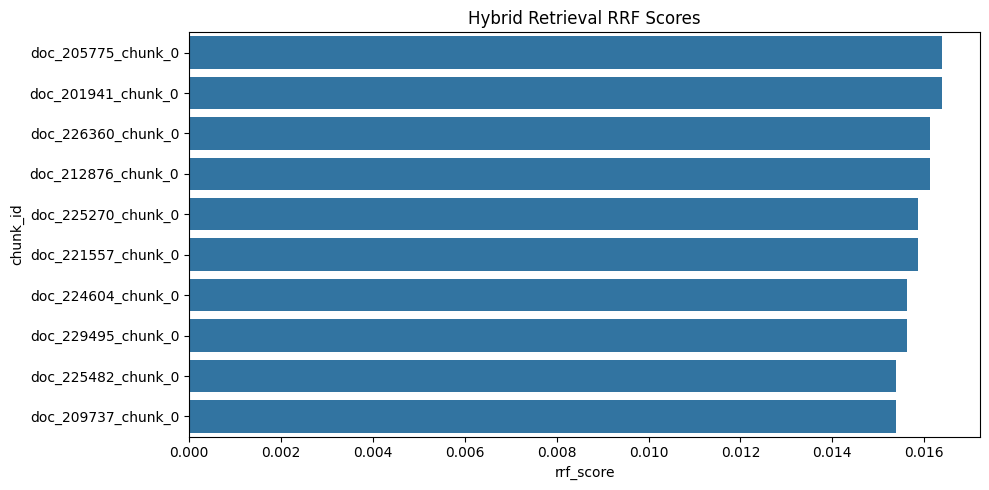

In [36]:
# ============================================================
# CELL 16 — VISUALIZE RRF SCORES
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.barplot(
    data=hybrid_results.head(10),
    x="rrf_score",
    y="chunk_id"
)

plt.title("Hybrid Retrieval RRF Scores")

plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# CELL 17 — MULTI-QUERY TESTING
# ============================================================

test_queries = [
    "VPN timeout after windows update",
    "outlook login issue",
    "printer not responding",
    "wifi connection unstable",
    "email synchronization problem"
]

evaluation_results = []

for query in test_queries:

    results = hybrid_search(
        query=query,
        top_k=5
    )

    evaluation_results.append({
        "query": query,

        "top_chunk_id": (
            results.iloc[0]["chunk_id"]
        ),

        "top_rrf_score": (
            results.iloc[0]["rrf_score"]
        )
    })

evaluation_df = pd.DataFrame(
    evaluation_results
)

print("=" * 60)
print("MULTI-QUERY EVALUATION")
print("=" * 60)

evaluation_df

MULTI-QUERY EVALUATION


,query,top_chunk_id,top_rrf_score
0,VPN timeout after windows update,doc_205775_chunk_0,0.016393
1,outlook login issue,doc_217532_chunk_0,0.016393
2,printer not responding,doc_201995_chunk_0,0.031498
3,wifi connection unstable,doc_224493_chunk_0,0.016393
4,email synchronization problem,doc_222399_chunk_0,0.032018


In [38]:
# ============================================================
# CELL 18 — EXPORT HYBRID EVALUATION
# ============================================================

EXPORT_PATH = (
    "../evaluation/hybrid_retrieval_results.csv"
)

evaluation_df.to_csv(
    EXPORT_PATH,
    index=False
)

print("=" * 60)
print("EVALUATION EXPORTED")
print("=" * 60)

print(f"Path:\n{EXPORT_PATH}")

EVALUATION EXPORTED
Path:
../evaluation/hybrid_retrieval_results.csv


In [39]:
# ============================================================
# CELL 19 — FINAL RETRIEVAL REPORT
# ============================================================

print("=" * 60)
print("FINAL HYBRID RETRIEVAL REPORT")
print("=" * 60)

print(f"FAISS Index Size        : {index.ntotal:,}")

print(f"BM25 Corpus Size        : {len(bm25_tokens):,}")

print(f"Metadata Rows           : {len(metadata_df):,}")

print(f"RRF Constant            : {RRF_K}")

print(f"Embedding Model         : {EMBEDDING_MODEL_NAME}")

print(f"Average Hybrid Score    : {hybrid_results['rrf_score'].mean():.4f}")

FINAL HYBRID RETRIEVAL REPORT
FAISS Index Size        : 230,088
BM25 Corpus Size        : 230,088
Metadata Rows           : 230,088
RRF Constant            : 60
Embedding Model         : sentence-transformers/all-MiniLM-L6-v2
Average Hybrid Score    : 0.0159
